# Загрузка данных и библиотек
---

In [150]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier

from sklearn.base import BaseEstimator

import matplotlib.pyplot as plt
import seaborn as sns
import copy

RANDOM_STATE = 0xFACED

In [3]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [4]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# EDA
---

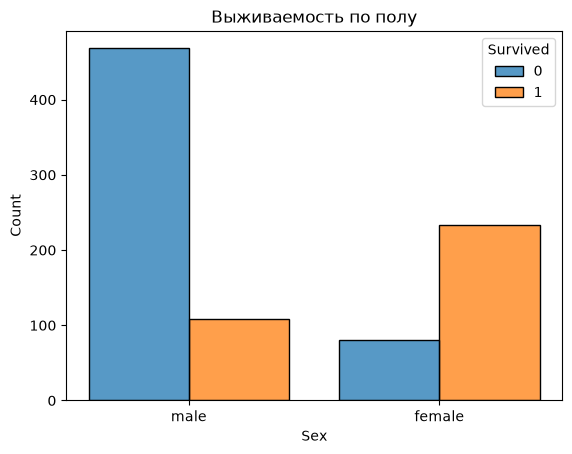

In [5]:
sns.histplot(data=train, x='Sex', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по полу')
plt.show()

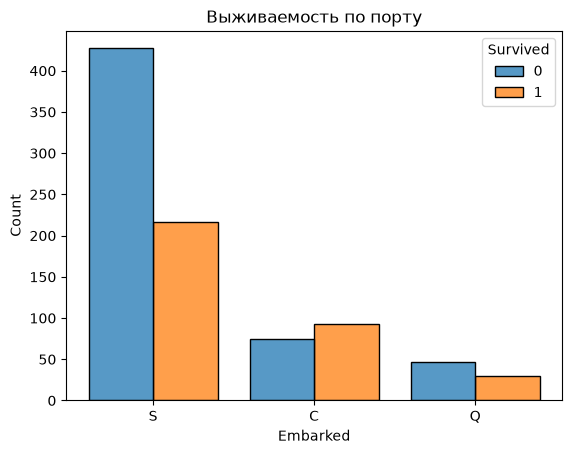

In [6]:
sns.histplot(data=train, x='Embarked', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по порту')
plt.show()

In [7]:
print(f"Пропуски в train по колонкам (из {train.shape[0]}):")
for col in train.columns:
    if train[col].isna().any():
        print(f"{col}: {train[col].isna().sum()}")

print(f"\nПропуски в test по колонкам (из {test.shape[0]}):")
for col in test.columns:
    if test[col].isna().any():
        print(f"{col}: {test[col].isna().sum()}")

Пропуски в train по колонкам (из 891):
Age: 177
Cabin: 687
Embarked: 2

Пропуски в test по колонкам (из 418):
Age: 86
Fare: 1
Cabin: 327


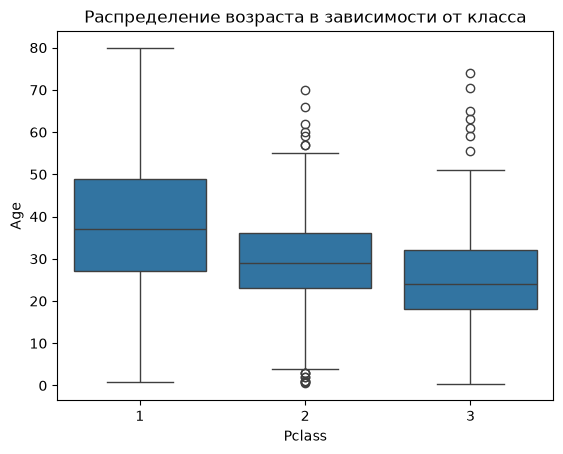

In [8]:
sns.boxplot(x='Pclass', y='Age', data=train)
plt.title('Распределение возраста в зависимости от класса')
plt.show()

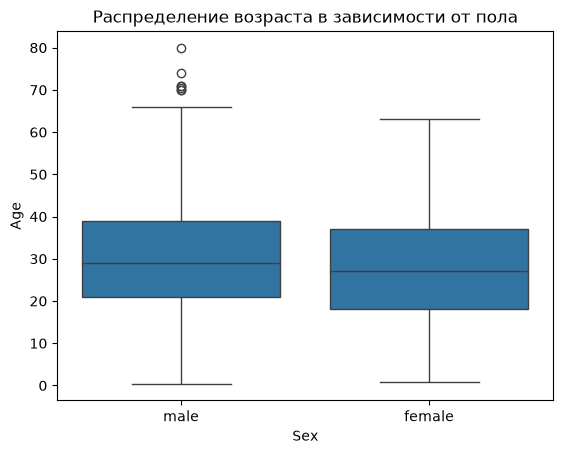

In [9]:
sns.boxplot(x='Sex', y='Age', data=train)
plt.title('Распределение возраста в зависимости от пола')
plt.show()

# Предобработка данных
---

Извлечем титул пассажира из колонки `Name`

In [10]:
train['Title'] = train['Name'].str.extract(r'([A-Za-z]+)\.')
test['Title'] = test['Name'].str.extract(r'([A-Za-z]+)\.')
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

In [11]:
print(train['Title'].value_counts())
print(test['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


In [12]:
other_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Jonkheer', 'Don', 'Sir', 'Lady', 'Countess', 'Dona']
train['Title'] = train['Title'].replace(other_titles, 'Other')
test['Title'] = test['Title'].replace(other_titles, 'Other')

train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')
test['Title'] = test['Title'].replace(['Mlle', 'Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')

train['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Other      23
Name: count, dtype: int64

In [13]:
train.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Other     0.347826
Mr        0.156673
Name: Survived, dtype: float64

In [14]:
train.groupby('Title')['Age'].mean().sort_values(ascending=False)

Title
Other     45.545455
Mrs       35.788991
Mr        32.368090
Miss      21.845638
Master     4.574167
Name: Age, dtype: float64

Заполним пропуски `Age` в зависимости от `Sex`, `Pclass`, `Title`

In [15]:
for dataset in (train, test):
    for sex in dataset['Sex'].unique():
        for pclass in dataset['Pclass'].unique():
            for title in dataset['Title'].unique():
                mean_age = dataset.loc[(dataset['Sex'] == sex) & 
                                       (dataset['Pclass'] == pclass) &
                                       (dataset['Title'] == title) &
                                       (dataset['Age'].notna()), 'Age'].mean()
                mask = (dataset['Age'].isna()) & (dataset['Sex'] == sex) & (dataset['Pclass'] == pclass) & (dataset['Title'] == title)
                dataset.loc[mask, 'Age'] = mean_age

Заменим порт `Embarked` на самый частый

In [16]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [17]:
test[test['Fare'].isna()]

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
152,1044,3,male,60.5,0,0,3701,NaN,NaN,S,Mr


In [18]:
test.loc[test['Fare'].isna(), 'Fare'] = test.loc[(test['Fare'].notna()) & (test['Sex'] == 'male') & (test['Pclass'] == 3) & (test['Title'] == 'Mr'), 'Fare'].mean()

Насчет номеров кабинок неодназначно, можно их просто удалить, так как данных крайне мало, но появилась идея создать новый бинарный признак - известен ли номер кабинки для пассажира

In [19]:
train['HasCabin'] = train['Cabin'].notna().astype(int)
test['HasCabin'] = test['Cabin'].notna().astype(int)
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,HasCabin
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs,1
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,0
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs,1
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr,0


In [20]:
pd.crosstab(train['HasCabin'], train['Survived'])

Survived,0,1
HasCabin,,
0,481,206
1,68,136


Не уверен, но как-будто признак обещает быть полезным, потому что большая часть людей, чья кабинка известна - выжили.

In [21]:
pd.crosstab(train['HasCabin'], train['Pclass'])

Pclass,1,2,3
HasCabin,,,
0,40,168,479
1,176,16,12


In [22]:
train['Sex'] = (train['Sex'] == 'female').astype(int)
test['Sex'] = (test['Sex'] == 'female').astype(int)

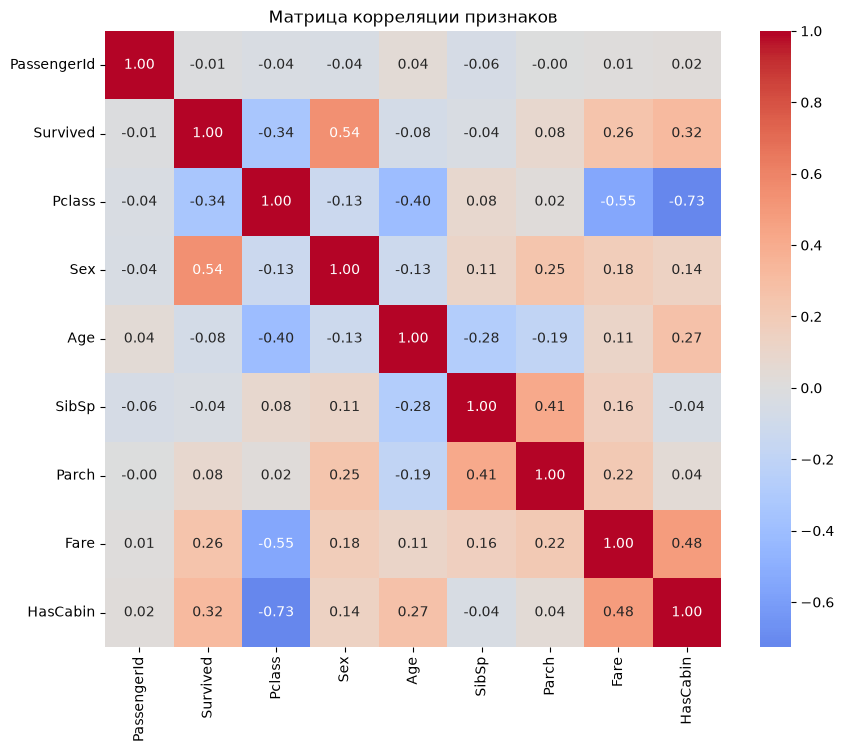

In [23]:
corr_matrix = train.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции признаков')
plt.show()

Хотя с другой стороны, подавляющая часть известных номеров принадлежит первому классу, и в `Pclass` как-будто уже заложена эта информация, поэтому `HasCabin` будет лишним возможно, узнаем дальше

ГИПОТЕЗА: социальный статус, упоминаемый в Name, влияет на выживаемость, проверим позже, а пока удалим эту колонку, а также Ticket

In [24]:
train.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)
test.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin
0,0,3,0,22.0,1,0,7.2500,S,Mr,0
1,1,1,1,38.0,1,0,71.2833,C,Mrs,1
2,1,3,1,26.0,0,0,7.9250,S,Miss,0
3,1,1,1,35.0,1,0,53.1000,S,Mrs,1
4,0,3,0,35.0,0,0,8.0500,S,Mr,0


Сохраняем датасет с категориальными переменными для CatBoost, для остальных моделей - применяем One-Hot-Encoding

In [25]:
train_cat = train.copy()
test_cat = test.copy()
train = pd.get_dummies(train, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'])
test = pd.get_dummies(test, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'])


Убираем лишние колонки после One-Hot-Encoding

In [26]:
drop_columns = ['Emb_Q', 'Title_Other']

train.drop(drop_columns, axis=1, inplace=True)
test.drop(drop_columns, axis=1, inplace=True)
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Emb_C,Emb_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,0,3,0,22.0,1,0,7.2500,0,False,True,False,False,True,False
1,1,1,1,38.0,1,0,71.2833,1,True,False,False,False,False,True
2,1,3,1,26.0,0,0,7.9250,0,False,True,False,True,False,False
3,1,1,1,35.0,1,0,53.1000,1,False,True,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,0,False,True,False,False,True,False


In [27]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Emb_C,Emb_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,3,0,34.5,0,0,7.8292,0,False,False,False,False,True,False
1,3,1,47.0,1,0,7.0000,0,False,True,False,False,False,True
2,2,0,62.0,0,0,9.6875,0,False,False,False,False,True,False
3,3,0,27.0,0,0,8.6625,0,False,True,False,False,True,False
4,3,1,22.0,1,1,12.2875,0,False,True,False,False,False,True


Масштабирование признаков

In [ ]:
X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

# Classic ML
---

## Наивный классификатор - baseline

In [29]:
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
accuracy = dummy_model.score(X_val, y_val)
print(f"Точность наивного классификатора: {accuracy:.2f}")

Точность наивного классификатора: 0.66


## Логистическая регрессия

In [30]:
def get_fitted_logistic_regression(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = [
        {
            'solver': ['lbfgs'],
            'penalty': ['l2'],
            'C': np.logspace(-3, 2, 12),
        },
        {
            'solver': ['liblinear'],
            'penalty': ['l1', 'l2'],
            'C': np.logspace(-3, 2, 12),
        },
        {
            'solver': ['saga'],
            'penalty': ['elasticnet'],
            'C': np.logspace(-3, 2, 12),
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    ]

    model = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, cv=5, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('LogisticRegression')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

logreg_model = get_fitted_logistic_regression(X_train_scaled, y_train, X_val_scaled, y_val)

LogisticRegression
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       118
           1       0.86      0.84      0.85        61

    accuracy                           0.90       179
   macro avg       0.89      0.88      0.89       179
weighted avg       0.90      0.90      0.90       179

            value
C        0.065793
penalty        l2
solver      lbfgs


c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [31]:
stats = {}

def get_accuracy_threshold(model, X_val, y_val, verbose=True):
    if hasattr(model, "predict_proba"):
        y_val_probs = model.predict_proba(X_val)[:, 1]
    elif isinstance(model, nn.Module):
        model.eval()
        with torch.no_grad():
            y_val_probs = torch.sigmoid(model(X_val)).cpu().numpy().flatten()
    
    best_threshold = 0.5
    best_accuracy = 0.0

    for threshold in np.arange(0.1, 0.9, 0.01):
        preds = (y_val_probs >= threshold).astype(int)
        current_accuracy = accuracy_score(y_val, preds)
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_threshold = threshold

    if verbose:
        print(f'best threshold: {best_threshold:.2f}')
        print(f'best accuracy:  {best_accuracy:.4f}')
    return best_accuracy, best_threshold

stats['LogisticRegression'] = get_accuracy_threshold(logreg_model, X_val_scaled, y_val)

best threshold: 0.43
best accuracy:  0.9050


Отображаем важность признаков

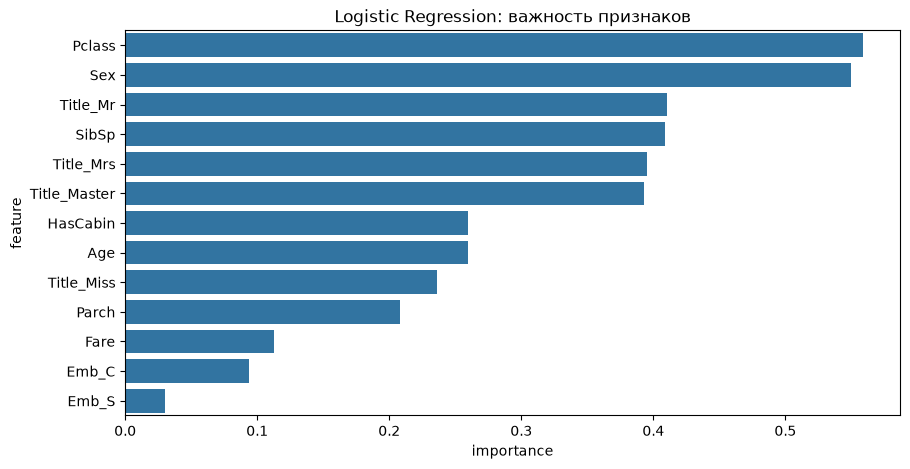

In [32]:
coefs = logreg_model.coef_[0]
features = X_train.columns

importance_df = pd.DataFrame({'feature': features, 'importance': np.abs(coefs)})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Logistic Regression: важность признаков')
plt.show()

## KNN

In [33]:
def get_fitted_knn(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'n_neighbors': np.arange(1, 50),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2, 3]
    }

    model = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('KNeighborsClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

knn_model = get_fitted_knn(X_train_scaled, y_train, X_val_scaled, y_val)

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       118
           1       0.81      0.77      0.79        61

    accuracy                           0.86       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.86      0.86      0.86       179

                 value
metric       manhattan
n_neighbors         16
p                    1
weights        uniform


Попробуем убрать колонки с титулами

In [ ]:
X_knn = train.drop(columns=['Survived', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs'])
X_knn_train, X_knn_val, y_knn_train, y_knn_val = train_test_split(X_knn, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_knn_train_scaled = scaler.fit_transform(X_knn_train)
X_knn_val_scaled = scaler.transform(X_knn_val)

In [35]:
knn_model = get_fitted_knn(X_knn_train_scaled, y_knn_train, X_knn_val_scaled, y_knn_val)

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       118
           1       0.90      0.77      0.83        61

    accuracy                           0.89       179
   macro avg       0.90      0.86      0.88       179
weighted avg       0.89      0.89      0.89       179

                 value
metric       manhattan
n_neighbors         24
p                    1
weights        uniform


In [36]:
stats['KNeighborsClassifier'] = get_accuracy_threshold(knn_model, X_knn_val_scaled, y_knn_val)

best threshold: 0.51
best accuracy:  0.8939


## Дерево решений

In [37]:
def get_fitted_decision_tree(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 2, 3, 4, 5, 7, 10, 12, 15], 
        'min_samples_split': np.arange(2, 30, 2),
        'min_samples_leaf': np.arange(1, 20, 2),
        'max_features': [None, 'sqrt', 'log2', 0.5, 0.7] 
    }

    model = RandomizedSearchCV(DecisionTreeClassifier(), param_distributions=param_grid, n_iter=300, cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if verbose:
        print('DecisionTreeClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

tree_model = get_fitted_decision_tree(X_train, y_train, X_val, y_val)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       118
           1       0.84      0.69      0.76        61

    accuracy                           0.85       179
   macro avg       0.85      0.81      0.82       179
weighted avg       0.85      0.85      0.85       179

                     value
min_samples_split        8
min_samples_leaf         1
max_features          None
max_depth                4
criterion          entropy


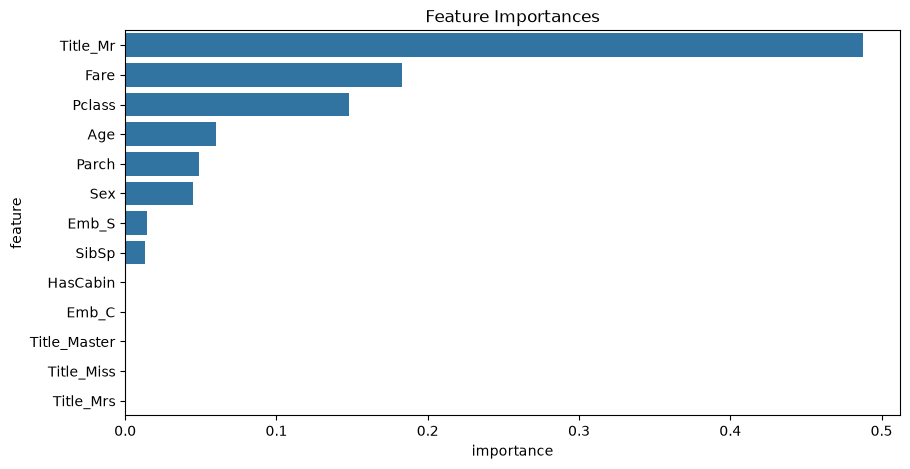

In [38]:
importances = tree_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importances')
plt.show()

Пропробуем убрать неважные признаки

In [ ]:
X_tree = train.drop(columns=['Survived', 'Title_Miss', 'Title_Mrs', 'Title_Master'])
X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(X_tree, y, test_size=0.2, random_state=RANDOM_STATE)

In [40]:
tree_model = get_fitted_decision_tree(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       118
           1       0.88      0.69      0.77        61

    accuracy                           0.86       179
   macro avg       0.86      0.82      0.84       179
weighted avg       0.86      0.86      0.86       179

                     value
min_samples_split        8
min_samples_leaf         1
max_features          None
max_depth                4
criterion          entropy


In [41]:
stats['DecisionTreeClassifier'] = get_accuracy_threshold(tree_model, X_tree_val, y_tree_val)

best threshold: 0.46
best accuracy:  0.8771


## Random Forest

In [42]:
def get_fitted_random_forest(X_train, y_train, X_val, y_val, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_samples': [0.5, 0.7, 0.9, None],
        'max_depth': [2, 3, 4, 5],
        'max_features': ['sqrt', 'log2', 0.4, 0.6],
        'min_samples_split': [2, 4, 5, 7, 10],
        'min_samples_leaf': [1, 2, 4, 5, 7, 10],
    }

    model = RandomizedSearchCV(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), param_grid, n_iter=100, cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if verbose:
        print('RandomForestClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

rf_model = get_fitted_random_forest(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       118
           1       0.83      0.80      0.82        61

    accuracy                           0.88       179
   macro avg       0.87      0.86      0.86       179
weighted avg       0.88      0.88      0.88       179

                     value
min_samples_split        7
min_samples_leaf         2
max_samples           None
max_features           0.4
max_depth                4
criterion          entropy


In [43]:
rf_model.set_params(n_estimators=300)
rf_model.fit(X_tree_train, y_tree_train)

stats['RandomForestClassifier'] = get_accuracy_threshold(rf_model, X_tree_val, y_tree_val)

best threshold: 0.45
best accuracy:  0.8827


## CatBoost

Подготовка данных для CatBoost

In [ ]:
X_cat = train_cat.drop('Survived', axis=1)
y_cat = train_cat['Survived']

X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE)

In [45]:
def get_fitted_catboost(X_train, y_train, X_val, y_val, cat_features, verbose=True):
    catboost_model = CatBoostClassifier(
        iterations=1500,
        depth=5,
        loss_function='Logloss',
        random_seed=42
    )
    if verbose: 
        print('CatBoostClassifier')
    catboost_model.fit(X_cat_train, y_cat_train, eval_set=(X_cat_val, y_cat_val), cat_features=cat_features, early_stopping_rounds=100, verbose=100*verbose)
    y_cat_pred = catboost_model.predict(X_cat_val)
    if verbose:
        print(classification_report(y_cat_val, y_cat_pred))
    return catboost_model

catboost_model = get_fitted_catboost(X_cat_train, y_cat_train, X_cat_val, y_cat_val, cat_features=['Title', 'Embarked'])

CatBoostClassifier
Learning rate set to 0.024427
0:	learn: 0.6782958	test: 0.6770208	best: 0.6770208 (0)	total: 174ms	remaining: 4m 20s
100:	learn: 0.3940121	test: 0.3540627	best: 0.3540627 (100)	total: 2.01s	remaining: 27.8s
200:	learn: 0.3592561	test: 0.3383902	best: 0.3383902 (200)	total: 3.93s	remaining: 25.4s
300:	learn: 0.3396585	test: 0.3310550	best: 0.3310550 (300)	total: 5.78s	remaining: 23s
400:	learn: 0.3161156	test: 0.3269383	best: 0.3268800 (398)	total: 7.82s	remaining: 21.4s
500:	learn: 0.2925793	test: 0.3227621	best: 0.3219660 (489)	total: 9.84s	remaining: 19.6s
600:	learn: 0.2735759	test: 0.3206213	best: 0.3198256 (593)	total: 11.7s	remaining: 17.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3198255805
bestIteration = 593

Shrink model to first 594 iterations.
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       118
           1       0.86      0.79      0.82        61

    accuracy           

In [46]:
stats['CatBoostClassifier'] = get_accuracy_threshold(catboost_model, X_cat_val, y_cat_val)

best threshold: 0.42
best accuracy:  0.8994


## LightGBM

In [ ]:
X_lgbm = train.drop(columns=['Survived'])
X_lgbm_train, X_lgbm_val, y_lgbm_train, y_lgbm_val = train_test_split(X_lgbm, y, test_size=0.2, random_state=RANDOM_STATE)

In [48]:
def get_fitted_lightgbm(X_train, y_train, X_val, y_val, verbose=True):
    lgbm_model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'num_leaves': np.arange(5, 20, 3),
        'max_depth': [-1, 3, 5, 7],
        'min_child_samples': [10, 15, 20, 25, 30]
    }

    model = RandomizedSearchCV(lgbm_model, param_grid, n_iter=200, scoring='accuracy', cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    if verbose:
        print('LGBMClassifier')
        print(classification_report(y_val, y_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

lgbm_model = get_fitted_lightgbm(X_lgbm_train, y_lgbm_train, X_lgbm_val, y_lgbm_val)

LGBMClassifier
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       118
           1       0.84      0.79      0.81        61

    accuracy                           0.88       179
   macro avg       0.87      0.86      0.86       179
weighted avg       0.88      0.88      0.88       179

                      value
num_leaves          11.0000
n_estimators       200.0000
min_child_samples   25.0000
max_depth            7.0000
learning_rate        0.0325


In [49]:
stats['LGBMClassifier'] = get_accuracy_threshold(lgbm_model, X_lgbm_val, y_lgbm_val)

best threshold: 0.32
best accuracy:  0.8827


## XGBoost

In [50]:
def get_fitted_xgboost(X_train, y_train, X_val, y_val, verbose=True):
    xgb_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)

    param_grid = {
        'n_estimators': np.arange(50, 301, 50),
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 2, 4, 6, 8, 10],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }

    model = RandomizedSearchCV(xgb_model, param_grid, n_iter=100, scoring='accuracy', cv=5, n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X_tree_train, y_tree_train)
    y_xgb_pred = model.predict(X_tree_val)
    if verbose:
        print('XGBClassifier')
        print(classification_report(y_tree_val, y_xgb_pred))
        print(pd.DataFrame.from_dict(model.best_params_, orient='index', columns=['value']))
    return model.best_estimator_

xgb_model = get_fitted_xgboost(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

XGBClassifier
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       118
           1       0.86      0.79      0.82        61

    accuracy                           0.88       179
   macro avg       0.88      0.86      0.87       179
weighted avg       0.88      0.88      0.88       179

                     value
subsample           0.6000
n_estimators      100.0000
min_child_weight    4.0000
max_depth           7.0000
learning_rate       0.0325
colsample_bytree    0.6000


In [51]:
stats['XGBClassifier'] = get_accuracy_threshold(xgb_model, X_tree_val, y_tree_val)

best threshold: 0.42
best accuracy:  0.8827


## Итоги по Classic ML

In [52]:
def print_sorted_stats(stats):
    stats = dict(sorted(stats.items(), key=lambda x: x[1][0], reverse=True))

    print('┌' + '─' * 24 + '┬' + '─' * 10 + '┬' + '─' * 11 + '┐')
    print(f"│ {'Classifier':<22} │ {'Accuracy':<8} │ {'Threshold':<9} │")
    print('├' + '─' * 24 + '┼' + '─' * 10 + '┼' + '─' * 11 + '┤')
    for model_name, (accuracy, threshold) in stats.items():
        print(f"│ {model_name:<22} │ {accuracy:<8.4f} │ {threshold:<10.2f}│")
    print('└' + '─' * 24 + '┴' + '─' * 10 + '┴' + '─' * 11 + '┘')

print_sorted_stats(stats)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ LogisticRegression     │ 0.9050   │ 0.43      │
│ CatBoostClassifier     │ 0.8994   │ 0.42      │
│ KNeighborsClassifier   │ 0.8939   │ 0.51      │
│ RandomForestClassifier │ 0.8827   │ 0.45      │
│ LGBMClassifier         │ 0.8827   │ 0.32      │
│ XGBClassifier          │ 0.8827   │ 0.42      │
│ DecisionTreeClassifier │ 0.8771   │ 0.46      │
└────────────────────────┴──────────┴───────────┘


# Deep Learning
---

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [54]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Первая версия

In [55]:
class NN1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 16)
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        return x

input_dim = X_train_tensor.shape[1]
nn1_model = NN1(input_dim).to(device)

In [56]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn1_model.parameters(), lr=0.001)

In [57]:
EPOCHS = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(EPOCHS):
    nn1_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn1_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn1_model.eval()
    with torch.no_grad():
        y_val_pred = nn1_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')

[EPOCH  10/100] train_loss: 0.5606, train_acc: 0.7949 | val_loss: 0.4493, val_acc: 0.8771
[EPOCH  20/100] train_loss: 0.5077, train_acc: 0.8216 | val_loss: 0.4234, val_acc: 0.8939
[EPOCH  30/100] train_loss: 0.5087, train_acc: 0.8315 | val_loss: 0.4159, val_acc: 0.8827
[EPOCH  40/100] train_loss: 0.4891, train_acc: 0.8357 | val_loss: 0.4205, val_acc: 0.8883
[EPOCH  50/100] train_loss: 0.4726, train_acc: 0.8427 | val_loss: 0.4180, val_acc: 0.8883
[EPOCH  60/100] train_loss: 0.4662, train_acc: 0.8357 | val_loss: 0.4224, val_acc: 0.8715
[EPOCH  70/100] train_loss: 0.4612, train_acc: 0.8357 | val_loss: 0.4240, val_acc: 0.8715
[EPOCH  80/100] train_loss: 0.4806, train_acc: 0.8357 | val_loss: 0.4311, val_acc: 0.8715
[EPOCH  90/100] train_loss: 0.4614, train_acc: 0.8371 | val_loss: 0.4347, val_acc: 0.8659
[EPOCH 100/100] train_loss: 0.4490, train_acc: 0.8385 | val_loss: 0.4374, val_acc: 0.8659


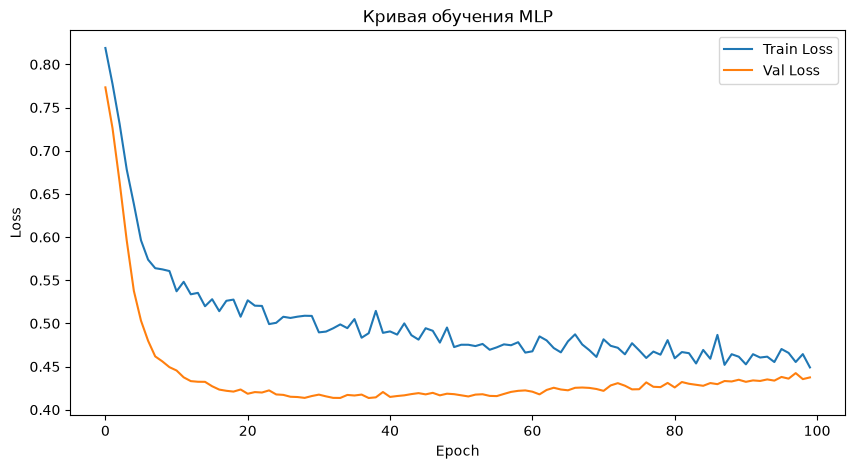

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Кривая обучения MLP')
plt.show()

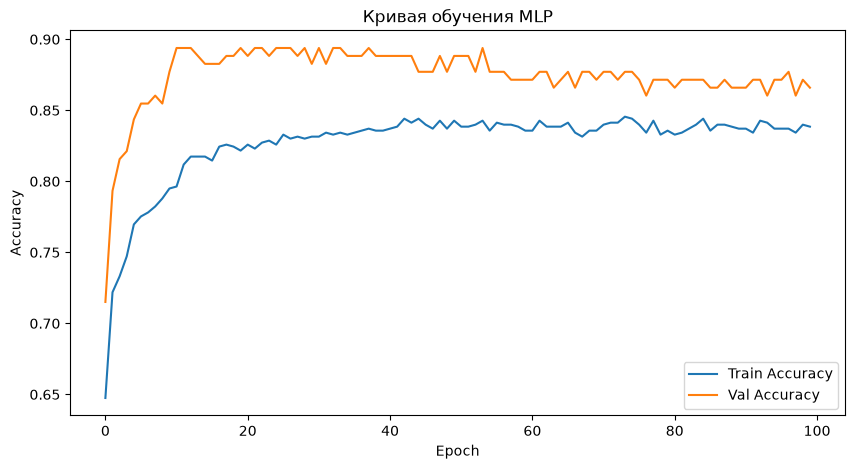

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Кривая обучения MLP')
plt.show()

In [60]:
stats['NN1'] = get_accuracy_threshold(nn1_model, X_val_tensor, y_val)

best threshold: 0.61
best accuracy:  0.8883


## Добавляем BatchNorm, DropOut, Early Stopping

In [61]:
class NN2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn2_model = NN2(input_dim).to(device)

In [62]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn2_model.parameters(), lr=0.001, weight_decay=1e-4)

In [63]:
EPOCHS = 150
train_losses, val_losses = [], []
train_acc, val_acc = [], []

best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    nn2_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn2_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn2_model.eval()
    with torch.no_grad():
        y_val_pred = nn2_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(nn2_model.state_dict())
    
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
        

[EPOCH  10/150] train_loss: 0.5783, train_acc: 0.8034 | val_loss: 0.4684, val_acc: 0.8659
[EPOCH  20/150] train_loss: 0.5532, train_acc: 0.8146 | val_loss: 0.4283, val_acc: 0.8939
[EPOCH  30/150] train_loss: 0.5379, train_acc: 0.8244 | val_loss: 0.4249, val_acc: 0.8994
[EPOCH  40/150] train_loss: 0.5319, train_acc: 0.8118 | val_loss: 0.4301, val_acc: 0.8994
[EPOCH  50/150] train_loss: 0.5168, train_acc: 0.8146 | val_loss: 0.4247, val_acc: 0.9106
[EPOCH  60/150] train_loss: 0.5217, train_acc: 0.8202 | val_loss: 0.4282, val_acc: 0.8939
[EPOCH  70/150] train_loss: 0.5285, train_acc: 0.8244 | val_loss: 0.4322, val_acc: 0.8994
[EPOCH  80/150] train_loss: 0.5080, train_acc: 0.8230 | val_loss: 0.4310, val_acc: 0.8827
[EPOCH  90/150] train_loss: 0.4964, train_acc: 0.8371 | val_loss: 0.4309, val_acc: 0.9050
[EPOCH 100/150] train_loss: 0.5064, train_acc: 0.8244 | val_loss: 0.4287, val_acc: 0.8939
[EPOCH 110/150] train_loss: 0.5121, train_acc: 0.8216 | val_loss: 0.4330, val_acc: 0.8771
[EPOCH 120

In [64]:
stats['NN2'] = get_accuracy_threshold(nn2_model, X_val_tensor, y_val)

best threshold: 0.56
best accuracy:  0.8939


## Добавляем Scheduler, меняем функции активации

In [65]:
class NN3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.silu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.silu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.silu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.silu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)

In [66]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)

In [67]:
def get_fitted_nn(nn_model, train_loader, X_val, y_val, scheduler, EPOCHS, early_stopping=True, verbose=True):
    train_losses, val_losses = [], []
    train_acc, val_acc = [], []
    if early_stopping:
        best_val_loss = float('inf')
        best_model_weights = None

    for epoch in range(EPOCHS):
        nn_model.train()
        train_loss = 0
        true_answer = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = nn_model(X_batch)
            y_batch = y_batch.view(-1, 1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(y_pred)
            preds_classes = (probs >= 0.5).float()
            true_answer += (preds_classes == y_batch).sum().item()
        
        train_losses.append(train_loss / len(train_loader))
        train_acc.append(true_answer / len(y_train_tensor))

        nn_model.eval()
        with torch.no_grad():
            y_val_pred = nn_model(X_val)
            y_val_target = y_val.view(-1, 1)
            val_loss = criterion(y_val_pred, y_val_target).item()

            val_probs = torch.sigmoid(y_val_pred)
            val_preds_classes = (val_probs >= 0.5).float()
            val_true_answer = (val_preds_classes == y_val_target).sum().item()

        val_losses.append(val_loss)
        val_acc.append(val_true_answer / len(y_val))

        if early_stopping and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(nn_model.state_dict())
        scheduler.step(val_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
    if early_stopping:
        nn_model.load_state_dict(best_model_weights)
        nn_model.eval()
    return nn_model, (train_losses, val_losses, train_acc, val_acc)


nn3_model, nn_stats = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=150)
train_losses, val_losses, train_acc, val_acc = nn_stats

[EPOCH  10/150] train_loss: 0.5317, train_acc: 0.8118 | val_loss: 0.4400, val_acc: 0.8771
[EPOCH  20/150] train_loss: 0.5113, train_acc: 0.8202 | val_loss: 0.4278, val_acc: 0.8994
[EPOCH  30/150] train_loss: 0.5139, train_acc: 0.8230 | val_loss: 0.4408, val_acc: 0.8939
[EPOCH  40/150] train_loss: 0.5213, train_acc: 0.8272 | val_loss: 0.4323, val_acc: 0.8883
[EPOCH  50/150] train_loss: 0.5073, train_acc: 0.8272 | val_loss: 0.4354, val_acc: 0.8883
[EPOCH  60/150] train_loss: 0.5233, train_acc: 0.8132 | val_loss: 0.4297, val_acc: 0.8939
[EPOCH  70/150] train_loss: 0.5213, train_acc: 0.8034 | val_loss: 0.4304, val_acc: 0.8883
[EPOCH  80/150] train_loss: 0.5128, train_acc: 0.8160 | val_loss: 0.4353, val_acc: 0.8883
[EPOCH  90/150] train_loss: 0.5170, train_acc: 0.8244 | val_loss: 0.4319, val_acc: 0.8994
[EPOCH 100/150] train_loss: 0.5288, train_acc: 0.8258 | val_loss: 0.4318, val_acc: 0.8939
[EPOCH 110/150] train_loss: 0.5179, train_acc: 0.8090 | val_loss: 0.4374, val_acc: 0.8827
[EPOCH 120

In [68]:
stats['NN3'] = get_accuracy_threshold(nn3_model, X_val_tensor, y_val)

best threshold: 0.53
best accuracy:  0.9050


## Итоги по Classic ML & DL

In [69]:
print_sorted_stats(stats)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ LogisticRegression     │ 0.9050   │ 0.43      │
│ NN3                    │ 0.9050   │ 0.53      │
│ CatBoostClassifier     │ 0.8994   │ 0.42      │
│ KNeighborsClassifier   │ 0.8939   │ 0.51      │
│ NN2                    │ 0.8939   │ 0.56      │
│ NN1                    │ 0.8883   │ 0.61      │
│ RandomForestClassifier │ 0.8827   │ 0.45      │
│ LGBMClassifier         │ 0.8827   │ 0.32      │
│ XGBClassifier          │ 0.8827   │ 0.42      │
│ DecisionTreeClassifier │ 0.8771   │ 0.46      │
└────────────────────────┴──────────┴───────────┘


# Feature Engineering
---

Добавим следующие признаки:
- `Family_Size` - общее кол-во человек в семье
- `Is_Alone` - одинокий ли человек
- `Age_Class` - произведение возраста и номера класса
- `Deck` - название палубы из номера каюты
- `Fare_Per_Person` - цена билета на одного человека
- `Title` - обработаем редкие титулы более точно
- `Is_Mother` - статус Мать
- `Family_Survival` - живучесть группы / семьи

Напишем итоговый препроцессинг

In [171]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
df = pd.concat([train, test], sort=False).reset_index(drop=True)

def preprocessing(df):
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'Unknown')
    df['Deck'] = df['Deck'].replace({'T': 'Unknown', 'G': 'F'})

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_dict = {
        'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
        'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Sir': 'Royalty', 'Countess': 'Royalty', 'Lady': 'Royalty', 'Dona': 'Royalty',
        'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss', 'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master'
    }
    df['Title'] = df['Title'].map(title_dict)

    df['Is_Mother'] = 0
    df.loc[(df['Age'] > 18) & (df['Sex'] == 'female') & (df['Parch'] > 0), 'Is_Mother'] = 1

    df['LastName'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

    df['Group_ID'] = df['LastName'] + '_' + df['Ticket']

    df['Family_Survival'] = 0.5
    for grp, group_df in df.groupby('Group_ID'):
        if len(group_df) > 1:
            for ind, row in group_df.iterrows():
                other_members = group_df.drop(ind)
                max_s = other_members['Survived'].max()
                min_s = other_members['Survived'].min()
                if max_s == 1.0:
                    df.loc[ind, 'Family_Survival'] = 1.0
                elif min_s == 0.0:
                    df.loc[ind, 'Family_Survival'] = 0.0
    df = df.drop(columns=['LastName', 'Group_ID'])

    # Старая предобработка
    for sex in df['Sex'].unique():
        for pclass in df['Pclass'].unique():
            for title in df['Title'].unique():
                mean_age = df.loc[(df['Sex'] == sex) & 
                                    (df['Pclass'] == pclass) &
                                    (df['Title'] == title) &
                                    (df['Age'].notna()), 'Age'].mean()
                mask = (df['Age'].isna()) & (df['Sex'] == sex) & (df['Pclass'] == pclass) & (df['Title'] == title)
                df.loc[mask, 'Age'] = mean_age
    
    df['Age_Class'] = df['Age'] * df['Pclass']
    
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    df.loc[df['Fare'].isna(), 'Fare'] = df.loc[(df['Fare'].notna()) & (df['Sex'] == 'male') & (df['Pclass'] == 3) & (df['Title'] == 'Mr'), 'Fare'].mean()

    ticket_counts = df['Ticket'].value_counts()
    df['Ticket_Frequency'] = df['Ticket'].map(ticket_counts)
    df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']

    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df.drop('Cabin', axis=1, inplace=True)
    df['Sex'] = (df['Sex'] == 'female').astype(int)
    
    df.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)

    df_cat = df.copy()
    train_cat = df_cat[df_cat['Survived'].notnull()].copy()
    test_cat = df_cat[df_cat['Survived'].isnull()].copy().drop(columns=['Survived'])

    df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], prefix=['Emb', 'Title', 'Deck'])

    drop_columns = ['Emb_Q', 'Deck_Unknown', 'Title_Officer', 'Name']
    df.drop(drop_columns, axis=1, inplace=True)

    train = df[df['Survived'].notnull()].copy()
    test = df[df['Survived'].isnull()].copy().drop(columns=['Survived'])

    return train, test, train_cat, test_cat

train, test, train_cat, test_cat = preprocessing(df)

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

X_cat = train_cat.drop('Survived', axis=1)
y_cat = train_cat['Survived']
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.2, random_state=RANDOM_STATE)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [98]:
stats_new = {}
logreg_model = get_fitted_logistic_regression(X_train_scaled, y_train, X_val_scaled, y_val, verbose=False)
stats_new['LogisticRegression'] = get_accuracy_threshold(logreg_model, X_val_scaled, y_val, verbose=False)

c:\Users\MSI\my\programming\ML\final_project\titanic\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [99]:
knn_model = get_fitted_knn(X_knn_train, y_knn_train, X_knn_val, y_knn_val, verbose=False)
stats_new['KNeighborsClassifier'] = get_accuracy_threshold(knn_model, X_knn_val, y_knn_val, verbose=False)

In [100]:
tree_model = get_fitted_decision_tree(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
stats_new['DecisionTreeClassifier'] = get_accuracy_threshold(tree_model, X_tree_val, y_tree_val, verbose=False)

In [101]:
rf_model = get_fitted_random_forest(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
stats_new['RandomForestClassifier'] = get_accuracy_threshold(rf_model, X_tree_val, y_tree_val, verbose=False)

In [173]:
catboost_model = get_fitted_catboost(X_cat_train, y_cat_train, X_cat_val, y_cat_val, cat_features=['Name', 'Embarked', 'Deck', 'Title'], verbose=False)
stats_new['CatBoostClassifier'] = get_accuracy_threshold(catboost_model, X_cat_val, y_cat_val, verbose=False)

In [103]:
lgbm_model = get_fitted_lightgbm(X_lgbm_train, y_lgbm_train, X_lgbm_val, y_lgbm_val, verbose=False)
stats_new['LGBMClassifier'] = get_accuracy_threshold(lgbm_model, X_lgbm_val, y_lgbm_val, verbose=False)

In [104]:
xgb_model = get_fitted_xgboost(X_tree_train, y_tree_train, X_tree_val, y_tree_val, verbose=False)
stats_new['XGBClassifier'] = get_accuracy_threshold(xgb_model, X_tree_val, y_tree_val, verbose=False)

In [105]:
input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)
nn3_model, _ = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=150, verbose=False)
stats_new['NN3'] = get_accuracy_threshold(nn3_model, X_val_tensor, y_val, verbose=False)

In [174]:
print_sorted_stats(stats_new)

┌────────────────────────┬──────────┬───────────┐
│ Classifier             │ Accuracy │ Threshold │
├────────────────────────┼──────────┼───────────┤
│ CatBoostClassifier     │ 0.9106   │ 0.34      │
│ LogisticRegression     │ 0.9050   │ 0.31      │
│ NN3                    │ 0.8994   │ 0.35      │
│ RandomForestClassifier │ 0.8827   │ 0.53      │
│ LGBMClassifier         │ 0.8827   │ 0.32      │
│ XGBClassifier          │ 0.8827   │ 0.42      │
│ DecisionTreeClassifier │ 0.8547   │ 0.38      │
│ KNeighborsClassifier   │ 0.7877   │ 0.51      │
└────────────────────────┴──────────┴───────────┘


Результаты после добавления выше указанных признаков:

| Classifier                 | Accuracy 1 | Accuracy 2 | Threshold 1 | Threshold 2 |
|----------------------------|------------|------------|-------------|-------------|
|👑**NN2**                   | 0.9106     |🟢0.9162   | 0.55        | 0.51        |
|👑**NN3**                   | 0.9050     |🟢0.9162   | 0.61        | 0.62        |
| LogisticRegression         | 0.9050     |🟰0.9050   | 0.43        | 0.50        |
|👑**CatBoostClassifier**    | 0.8994     |🟢0.9162   | 0.42        | 0.40        |
| NN1                        | 0.8994     |🟢0.9050   | 0.57        | 0.50        |
| KNeighborsClassifier       | 0.8939     |🔴0.8771   | 0.51        | 0.48        |
|👑**RandomForestClassifier**| 0.8939     |🟢0.9162   | 0.48        | 0.51        |
|👑**XGBClassifier**         | 0.8883     |🟢0.9162   | 0.44        | 0.43        |
| LGBMClassifier             | 0.8827     |🟢0.9050   | 0.32        | 0.40        |
| DecisionTreeClassifier     | 0.8603     |🟢0.9106   | 0.39        | 0.41        |

# Ансамбли
---

Кандидаты для ансамбля:
- CatBoost
- Logistic Regression
- NN3

## Усреднение

In [108]:
probs_cb = catboost_model.predict_proba(X_cat_val)[:, 1]
probs_logreg = logreg_model.predict_proba(X_val_scaled)[:, 1]

nn3_model.eval()
with torch.no_grad():
    probs_nn3 = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

probs_ensemble = (probs_cb + probs_logreg + probs_nn3) / 3.0

ensemble_threshold = 0.5
ensemble_accuracy  = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    preds_ensemble = (probs_ensemble >= threshold).astype(int)
    current_accuracy = accuracy_score(y_val, preds_ensemble)

    if current_accuracy > ensemble_accuracy:
        ensemble_threshold = threshold
        ensemble_accuracy = current_accuracy

print(f'ensemble threshold: {ensemble_threshold:.2f}')
print(f'ensemble accuracy:  {ensemble_accuracy:.4f}')

ensemble threshold: 0.37
ensemble accuracy:  0.9106


## Stacking

In [110]:
estimators = [
    ('catboost', catboost_model),
    ('logreg', logreg_model)
]

### Через Логистическую регрессию

In [114]:
stacking_model_logreg = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_model_logreg.fit(X_train_scaled, y_train)
stacking_accuracy, stacking_threshold = get_accuracy_threshold(stacking_model_logreg, X_val_scaled, y_val)

best threshold: 0.32
best accuracy:  0.9106


### Через Ridge

In [121]:
stacking_model_ridge = StackingClassifier(
    estimators=estimators,
    final_estimator=RidgeClassifier(),
    cv=5,
    n_jobs=-1
)

stacking_model_ridge.fit(X_train_scaled, y_train)

y_stack_pred = stacking_model_ridge.predict(X_val_scaled)
print(f'best accuracy: {accuracy_score(y_val, y_stack_pred):.4f}')

best accuracy: 0.8939


### Ручной стэкинг (Предсказания вер-тей)

In [123]:
meta_features_val = {
    'cb': catboost_model.predict_proba(X_cat_val)[:, 1],
    'lr': logreg_model.predict_proba(X_val_scaled)[:, 1]
}
nn3_model.eval()
with torch.no_grad():
    meta_features_val['nn3'] = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

X_meta_val = pd.DataFrame(meta_features_val)
y_meta_val = y_val.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(X_meta_val))

meta_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta_val, y_meta_val)):
    X_train_fold, X_val_fold = X_meta_val.iloc[train_idx], X_meta_val.iloc[val_idx]
    y_train_fold, y_val_fold = y_meta_val[train_idx], y_meta_val[val_idx]
    
    meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
    meta_model.fit(X_train_fold, y_train_fold)
    
    # Записываем вероятности для валидационного фолда в общий массив
    oof_probs[val_idx] = meta_model.predict_proba(X_val_fold)[:, 1]
    
    # Сохраняем модель этого фолда
    meta_models.append(meta_model)


best_meta_threshold = 0.5
best_meta_accuracy = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    meta_preds = (oof_probs >= threshold).astype(int)
    current_accuracy = accuracy_score(y_meta_val, meta_preds)
    
    if current_accuracy > best_meta_accuracy:
        best_meta_accuracy = current_accuracy
        best_meta_threshold = threshold

print(f'meta-model threshold: {best_meta_threshold:.2f}')
print(f'meta-model accuracy:  {best_meta_accuracy:.4f}')

meta-model threshold: 0.32
meta-model accuracy:  0.9106


### Ручной стэкинг (Фичи + Вероятности)

In [175]:
# Получаем вероятности от всех моделей на валидационной выборке
prob_cat = catboost_model.predict_proba(X_cat_val)[:, 1]
prob_logreg = logreg_model.predict_proba(X_val_scaled)[:, 1]

nn3_model.eval()
with torch.no_grad():
    prob_nn3 = torch.sigmoid(nn3_model(X_val_tensor)).cpu().numpy().flatten()

# Объединяем ИСХОДНЫЕ признаки валидации и ПРЕДСКАЗАНИЯ моделей
X_meta_combined = X_train.copy().reset_index(drop=True)
X_meta_combined['prob_cat'] = prob_cat
X_meta_combined['prob_logreg'] = prob_logreg
X_meta_combined['prob_nn3'] = prob_nn3

y_meta_combined = y_val.values

# Делим мета-датасет
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_meta_combined, y_meta_combined, test_size=0.5, random_state=RANDOM_STATE, stratify=y_meta_combined
)

# Обучаем Логистическую регрессию
meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(X_m_train, y_m_train)

# Получаем финальные вероятности
y_final_probs = meta_model.predict_proba(X_m_test)[:, 1]

# Калибровка порога
best_meta_threshold = 0.5
best_meta_accuracy = 0.0

for threshold in np.arange(0.1, 0.9, 0.01):
    meta_preds = (y_final_probs >= threshold).astype(int)
    current_accuracy = accuracy_score(y_m_test, meta_preds)
    
    if current_accuracy > best_meta_accuracy:
        best_meta_accuracy = current_accuracy
        best_meta_threshold = threshold

print(f'BEST THRESHOLD: {best_meta_threshold:.2f}')
print(f'BEST ACCURACY:  {best_meta_accuracy:.4f}')

ValueError: X has 27 features, but LogisticRegression is expecting 26 features as input.

# Ответ для Kaggle
---

In [169]:
X_m_train.isna().sum()

Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
HasCabin       0
Emb_C          0
Emb_S          0
Title_Mr       0
prob_cat       0
prob_logreg    0
prob_nn3       0
dtype: int64

In [166]:
test.isna().sum()

Pclass              0
Sex                 0
Age                 0
SibSp               0
Parch               0
Fare                0
Family_Size         0
Is_Alone            0
Is_Mother           0
Family_Survival     0
Age_Class           0
Ticket_Frequency    0
Fare_Per_Person     0
HasCabin            0
Emb_C               0
Emb_S               0
Title_Master        0
Title_Miss          0
Title_Mr            0
Title_Mrs           0
Title_Royalty       0
Deck_A              0
Deck_B              0
Deck_C              0
Deck_D              0
Deck_E              0
Deck_F              0
dtype: int64

In [168]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
X_cat_test = test_cat[X_cat_train.columns].astype(X_cat_train.dtypes)
test_pool = Pool(X_cat_test, cat_features=['Name', 'Embarked', 'Deck', 'Title'])
X_test = test.reindex(columns=X_train.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test)

prob_cat = catboost_model.predict_proba(test_pool)[:, 1]
prob_logreg = logreg_model.predict_proba(X_test_scaled)[:, 1]
nn3_model.eval()
with torch.no_grad():
    prob_nn3 = torch.sigmoid(nn3_model(X_test_tensor)).cpu().numpy().flatten()

test

ValueError: X has 27 features, but LogisticRegression is expecting 26 features as input.

# Узнать, можно ли обучить мета модель на скалированных данных, будет ли это лучше
# Исправить препроцессинг - добавить обновление датасетов для кнн, деревьев
# Мета-модель обучалась на датасете дерева, а должна была на всех числовых признаках + предсказаниях моделей